In [1]:
# Zomato Data Analysis\n# This notebook can run on Kaggle or locally when the required dataset files are available.\n\nimport numpy as np\nimport pandas as pd\nimport os\n\nprint('Environment ready.')\n

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 🍽️ Zomato Data Analysis

## Objective
This project performs Exploratory Data Analysis (EDA) on the Zomato restaurant dataset
to understand restaurant ratings, locations, cuisines, pricing, customer votes,
online delivery and table-booking patterns.

The analysis focuses on extracting useful patterns and business-oriented insights
from the available restaurant data.

## 1. Data Understanding & Initial Analysis

In [3]:
# Load Zomato dataset
# Works both on Kaggle and locally after uploading/placing zomato.csv.
import os

possible_csv_paths = [
    "/kaggle/input/zomato/zomato.csv",
    "./zomato.csv",
    "/mnt/data/zomato.csv"
]

csv_path = next((p for p in possible_csv_paths if os.path.exists(p)), None)

if csv_path is None:
    raise FileNotFoundError(
        "zomato.csv not found. Please upload/place zomato.csv in the same folder as this notebook "
        "or add the Zomato dataset to Kaggle."
    )

df = pd.read_csv(csv_path, encoding="latin-1")
print("Dataset loaded from:", csv_path)
df.head()

Dataset loaded from: ./zomato.csv


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [5]:
# Basic information about the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 9551
Number of columns: 21

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [7]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [8]:
df.shape

(9551, 21)

In Data analysis what all things we do 
1. Missing values
2. Explore about the Numerical variables
 

In [9]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

<Axes: >

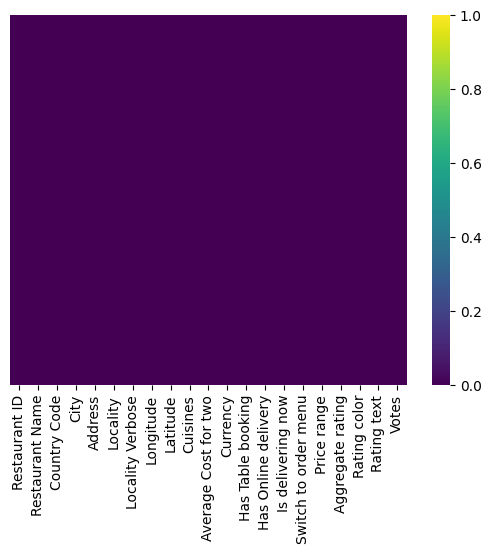

In [10]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=True,cmap='viridis')

In [11]:
# Load Country-Code file
possible_excel_paths = [
    "/kaggle/input/zomato/Country-Code.xlsx",
    "./Country-Code.xlsx",
    "/mnt/data/Country-Code.xlsx"
]

excel_path = next((p for p in possible_excel_paths if os.path.exists(p)), None)

if excel_path is None:
    raise FileNotFoundError(
        "Country-Code.xlsx not found. Please upload/place Country-Code.xlsx in the same folder "
        "as this notebook or add it to the Kaggle dataset."
    )

df_country = pd.read_excel(excel_path)
print("Country-Code loaded from:", excel_path)
df_country.head()

Country-Code loaded from: ./Country-Code.xlsx


,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


In [12]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [13]:
final_df=pd.merge(df,df_country,on='Country Code',how='left')

In [14]:
final_df.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines


In [15]:
country_names=final_df.Country.value_counts().index

In [16]:
country_val=final_df.Country.value_counts().values

([<matplotlib.patches.Wedge at 0x7feed0659550>,
 [Text(-1.082974277862112, 0.1927867046480056, 'India'),
  Text(1.0772816964394372, -0.22240536530526556, 'United States'),
  Text(1.0995865232164619, -0.030157552300104404, 'United Kingdom')],
 [Text(-0.5907132424702428, 0.10515638435345759, '94.39%'),
  Text(0.5876081980578747, -0.12131201743923574, '4.73%'),
  Text(0.5997744672089791, -0.01644957398187513, '0.87%')])

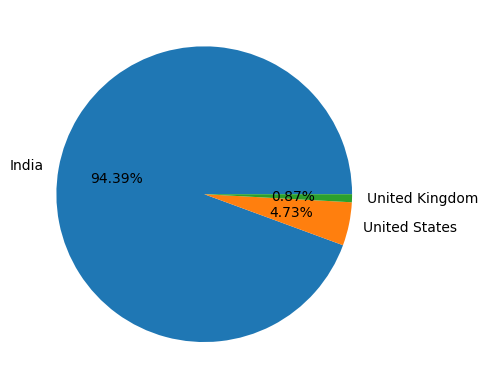

In [17]:
#Pie-chart-Top 3 countries that uses zomato
plt.pie(country_val[:3],labels=country_names[:3],autopct='%1.2f%%')

In [18]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [19]:
ratings=final_df.groupby(['Aggregate rating','Rating color','Rating text']).size().reset_index().rename(columns={0:'Rating Count'})

## Observation

1. Rating 4.5 to 4.9 is classified as Excellent.
2. Rating 4.0 to 4.4 is classified as Very Good.
3. Rating 3.5 to 3.9 is classified as Good.
4. Rating 3.0 to 3.4 is classified as Average.
5. Rating 2.5 to 2.9 is classified as Average.
6. Rating 2.0 to 2.4 is classified as Poor.
7. Rating 0 is treated separately because the dataset uses it for restaurants without an assigned rating.

The exact distribution can be understood from the rating table and charts below.


In [20]:
ratings

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


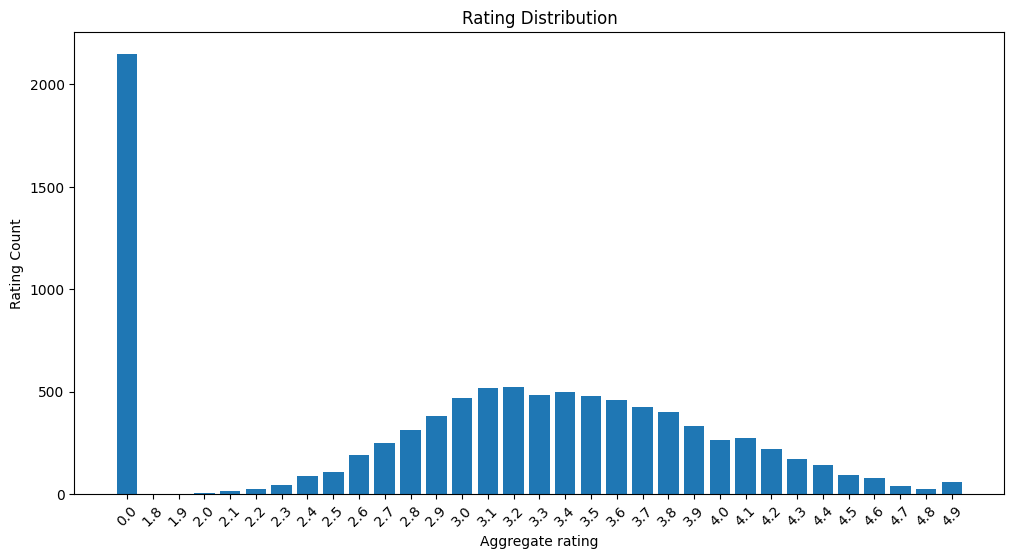

In [21]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
plt.bar(ratings['Aggregate rating'].astype(str), ratings['Rating Count'])
plt.xlabel('Aggregate rating')
plt.ylabel('Rating Count')
plt.title('Rating Distribution')
plt.xticks(rotation=45)
plt.show()


In [22]:
final_df[final_df['Rating color']=='White'].groupby('Country').size().reset_index()

,Country,0
0,Brazil,5
1,India,2139
2,United Kingdom,1
3,United States,3


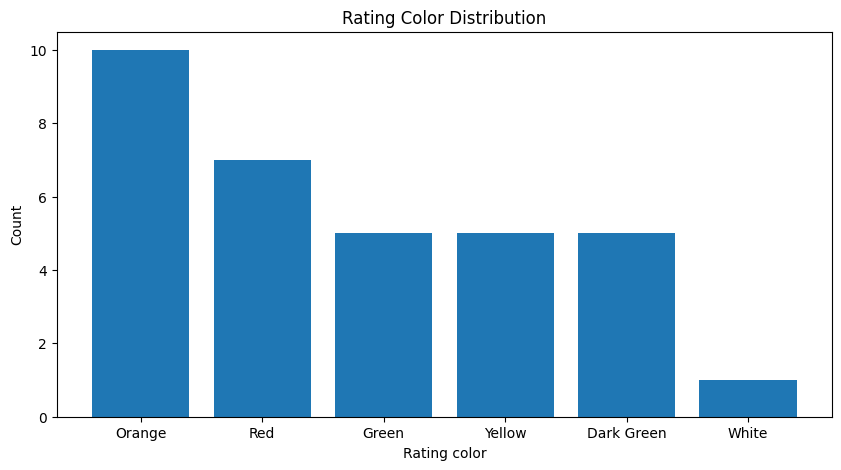

In [23]:
## Count plot
rating_color_counts = ratings['Rating color'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(rating_color_counts.index.astype(str), rating_color_counts.values)
plt.title("Rating Color Distribution")
plt.xlabel("Rating color")
plt.ylabel("Count")
plt.show()


In [24]:
final_df.groupby(['Aggregate rating','Country']).size().reset_index().head(5)

,Aggregate rating,Country,0
0,0.0,Brazil,5
1,0.0,India,2139
2,0.0,United Kingdom,1
3,0.0,United States,3
4,1.8,India,1


In [25]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [26]:
final_df[['Country','Currency']].groupby(['Country','Currency']).size().reset_index()

,Country,Currency,0
0,Australia,Dollar($),24
1,Brazil,Brazilian Real(R$),60
2,Canada,Dollar($),4
3,India,Indian Rupees(Rs.),8652
4,Indonesia,Indonesian Rupiah(IDR),21
5,New Zealand,NewZealand($),40
6,Phillipines,Botswana Pula(P),22
7,Qatar,Qatari Rial(QR),20
8,Singapore,Dollar($),20
9,South Africa,Rand(R),60


In [27]:
final_df[final_df['Has Online delivery'] =="Yes"].Country.value_counts()

Country
India    2423
UAE        28
Name: count, dtype: int64

In [28]:
final_df[['Has Online delivery','Country']].groupby(['Has Online delivery','Country']).size().reset_index()

,Has Online delivery,Country,0
0,No,Australia,24
1,No,Brazil,60
2,No,Canada,4
3,No,India,6229
4,No,Indonesia,21
5,No,New Zealand,40
6,No,Phillipines,22
7,No,Qatar,20
8,No,Singapore,20
9,No,South Africa,60


In [29]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [30]:
final_df.City.value_counts().index

Index(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad',
       'Bhubaneshwar', 'Lucknow', 'Ahmedabad', 'Amritsar', 'Guwahati',
       ...
       'Forrest', 'East Ballina', 'Huskisson', 'Inverloch', 'Lakeview',
       'Lakes Entrance', 'Mohali', 'Panchkula', 'Bandung', 'Randburg'],
      dtype='object', name='City', length=141)

In [31]:
city_values=final_df.City.value_counts().values
city_labels=final_df.City.value_counts().index

([<matplotlib.patches.Wedge at 0x7feed0313ed0>,
 [Text(-0.6145353730323401, 0.9123301350344637, 'New Delhi'),
  Text(0.06236774886414425, -1.0982305149200777, 'Gurgaon'),
  Text(0.878904221413572, -0.6614585169014024, 'Noida'),
  Text(1.0922218482114119, -0.1305811406354216, 'Faridabad'),
  Text(1.099946277419523, -0.010871374841004297, 'Ghaziabad')],
 [Text(-0.33520111256309454, 0.4976346191097074, '68.87%'),
  Text(0.03401877210771504, -0.5990348263200423, '14.07%'),
  Text(0.479402302589221, -0.36079555467349217, '13.59%'),
  Text(0.5957573717516791, -0.07122607671022996, '3.16%'),
  Text(0.5999706967742853, -0.00592984082236598, '0.31%')])

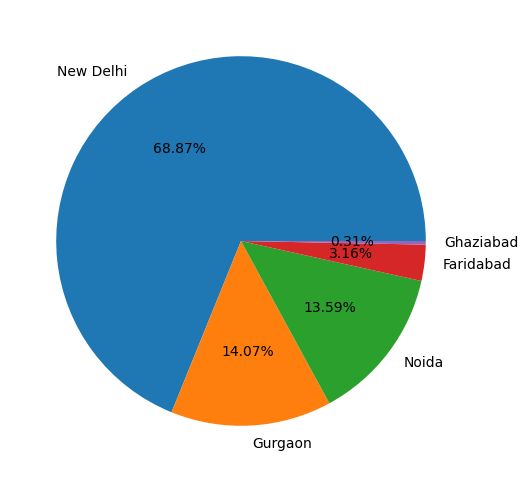

In [32]:
plt.pie(city_values[:5],labels=city_labels[:5],autopct='%1.2f%%')

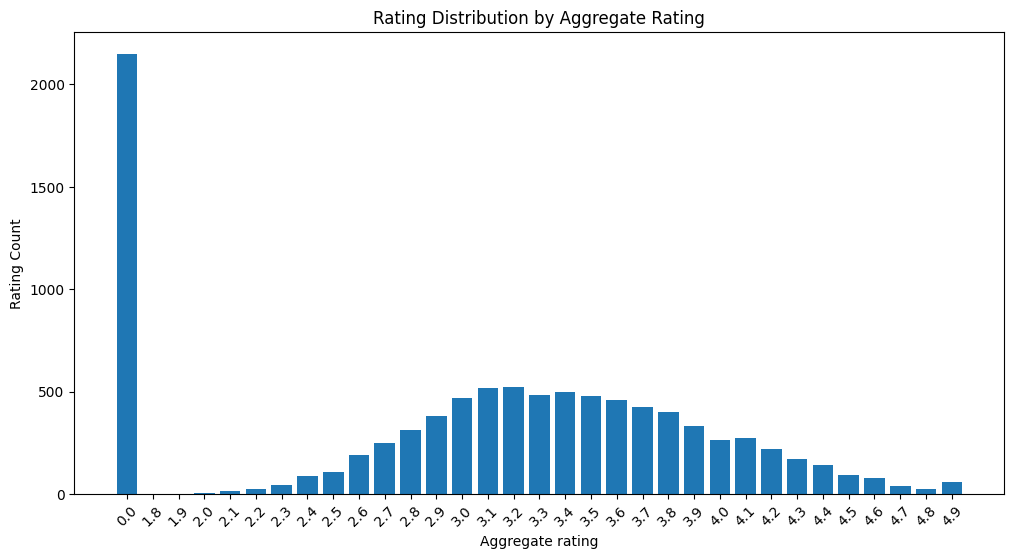

In [33]:
plt.figure(figsize=(12,6))
plt.bar(ratings["Aggregate rating"].astype(str), ratings["Rating Count"])
plt.xlabel("Aggregate rating")
plt.ylabel("Rating Count")
plt.title("Rating Distribution by Aggregate Rating")
plt.xticks(rotation=45)
plt.show()


## 2. Data Cleaning & Missing Value Analysis

In [34]:
# Check missing values in percentage
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Missing Percentage': missing_percent.round(2)
})

missing_table[missing_table['Missing Values'] > 0].sort_values(
    'Missing Values', ascending=False
)

,Missing Values,Missing Percentage
Cuisines,9,0.09


In [35]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 3. Country-wise Analysis

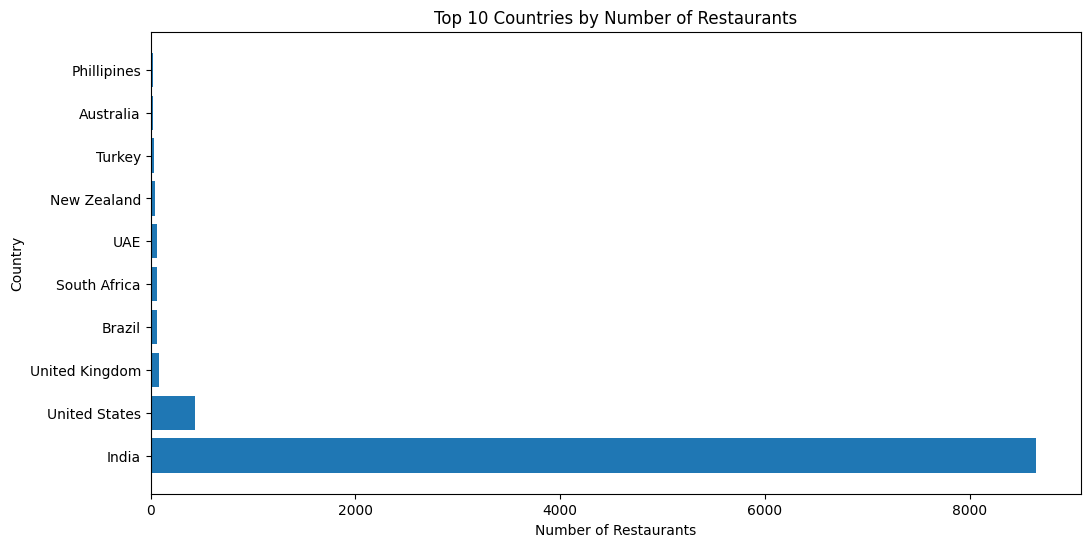

In [36]:
# Top 10 countries with the highest number of restaurants
top_countries = final_df['Country'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Country")
plt.show()

## 4. City-wise Analysis

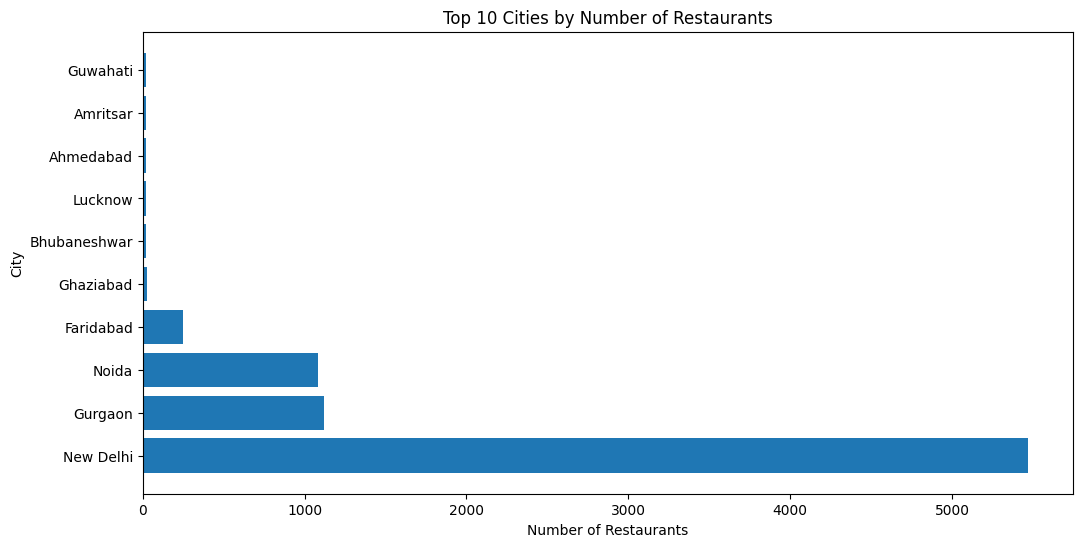

In [37]:
# Top 10 cities with the highest number of restaurants
top_cities = final_df['City'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.barh(top_cities.index, top_cities.values)
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

## 5. Rating Analysis

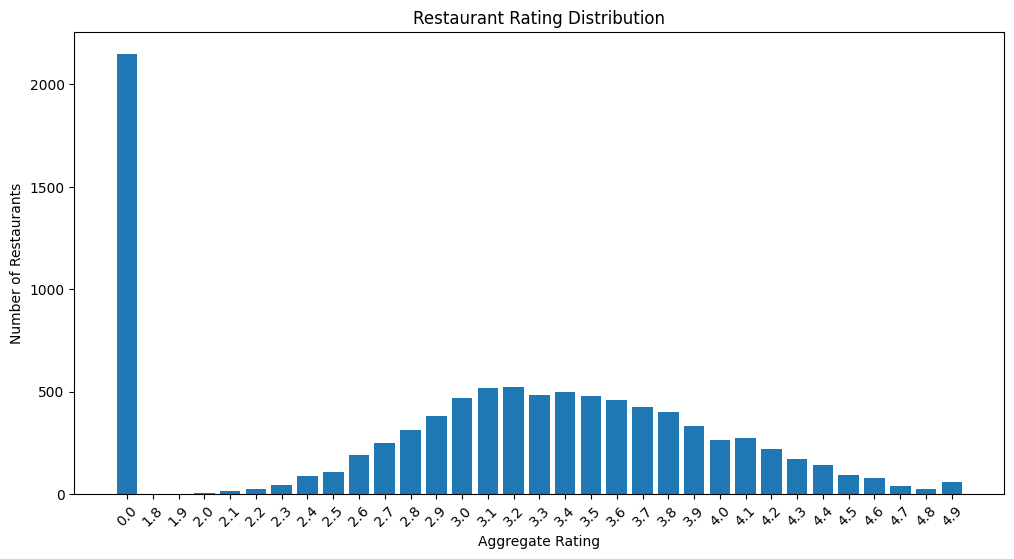

In [38]:
# Display rating distribution
rating_distribution = final_df['Aggregate rating'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(rating_distribution.index.astype(str), rating_distribution.values)
plt.title("Restaurant Rating Distribution")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

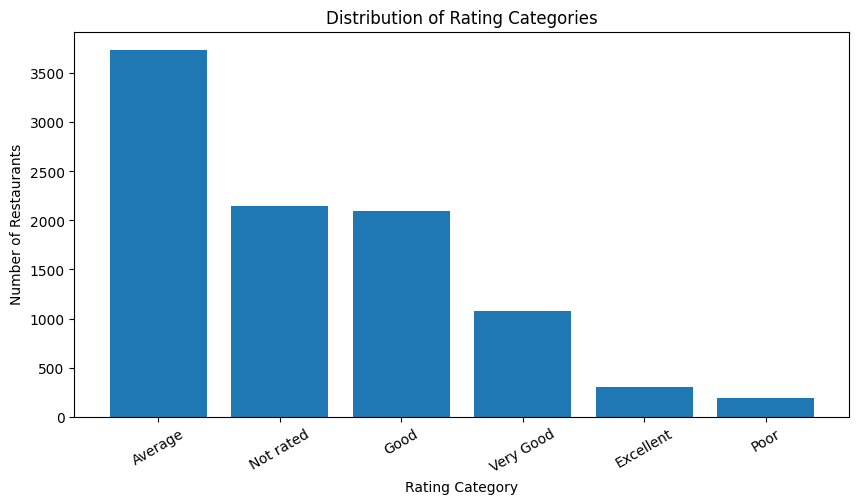

In [39]:
# Rating text distribution
rating_text_counts = final_df['Rating text'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(rating_text_counts.index, rating_text_counts.values)
plt.title("Distribution of Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=30)
plt.show()


## 6. Votes vs Rating Analysis

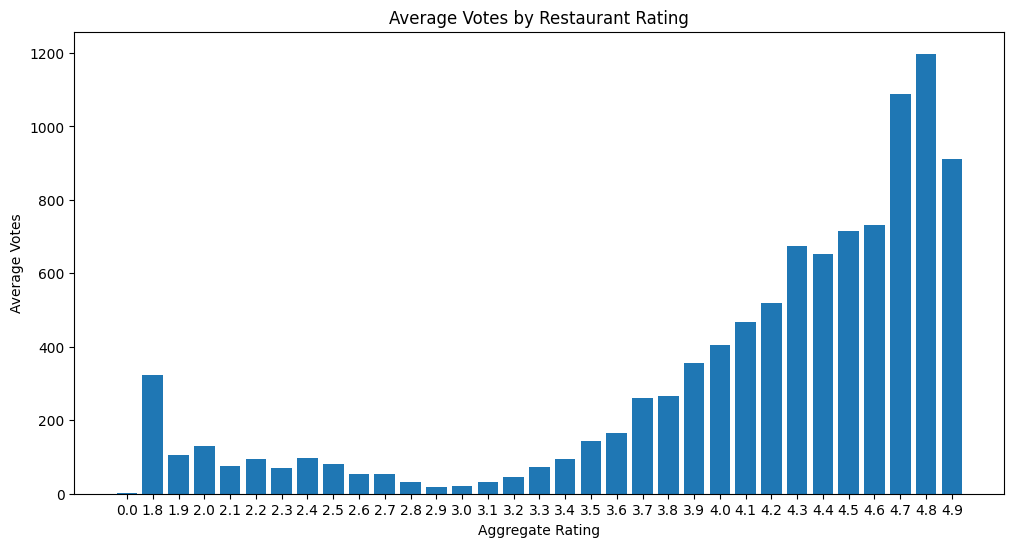

In [40]:
# Average votes received for each rating
votes_by_rating = final_df.groupby('Aggregate rating')['Votes'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.bar(votes_by_rating['Aggregate rating'].astype(str), votes_by_rating['Votes'])
plt.title("Average Votes by Restaurant Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Average Votes")
plt.show()

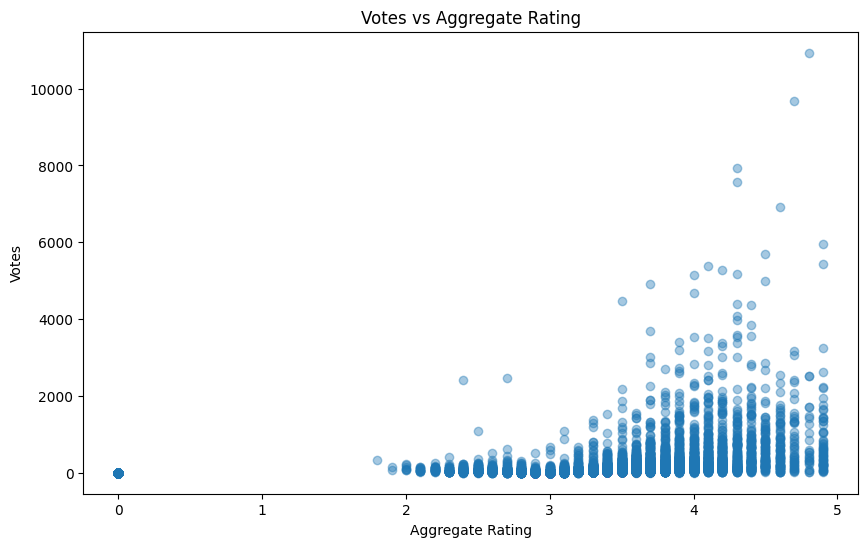

In [41]:
# Relationship between votes and ratings
plt.figure(figsize=(10,6))
plt.scatter(final_df['Aggregate rating'], final_df['Votes'], alpha=0.4)
plt.title("Votes vs Aggregate Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Votes")
plt.show()


## 7. Online Delivery Analysis

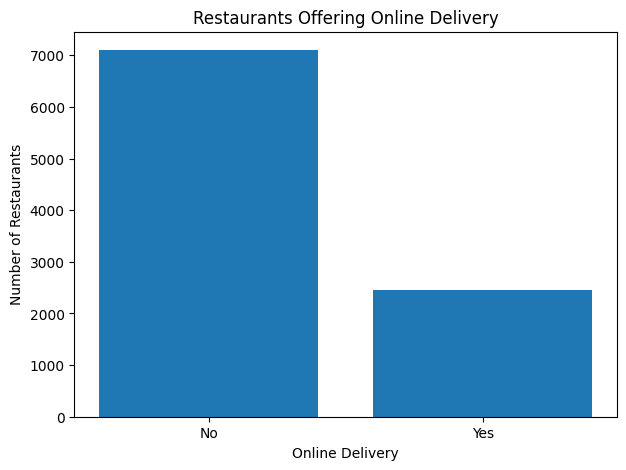

In [42]:
# Online delivery availability
delivery_counts = final_df['Has Online delivery'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(delivery_counts.index.astype(str), delivery_counts.values)
plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")
plt.show()

In [43]:
# Online delivery by rating
delivery_rating = pd.crosstab(
    final_df['Aggregate rating'],
    final_df['Has Online delivery']
)

delivery_rating

Has Online delivery,No,Yes
Aggregate rating,,
0.0,2052,96
1.8,0,1
1.9,1,1
2.0,2,5
2.1,4,11
2.2,7,20
2.3,14,33
2.4,42,45
2.5,42,68


## 8. Table Booking Analysis

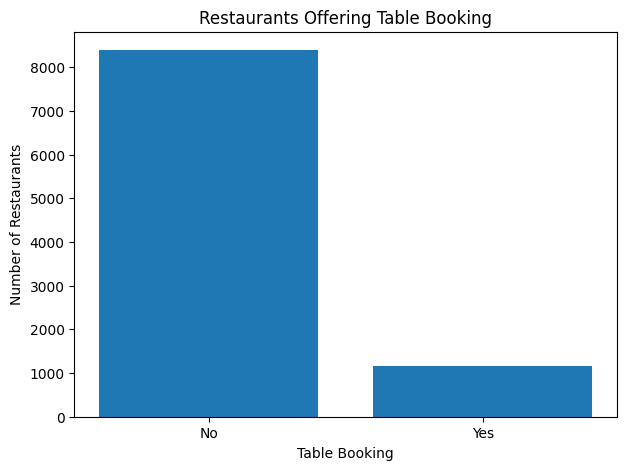

In [44]:
# Table booking availability
table_booking = final_df['Has Table booking'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(table_booking.index.astype(str), table_booking.values)
plt.title("Restaurants Offering Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")
plt.show()

## 9. Cost Analysis

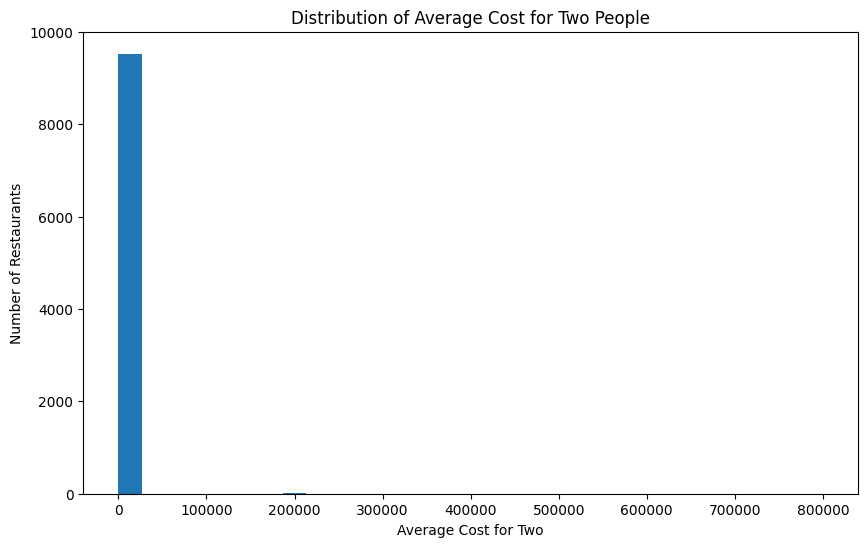

In [45]:
# Average cost for two people
plt.figure(figsize=(10,6))
cost_values = final_df['Average Cost for two'].dropna()
plt.hist(cost_values, bins=30)
plt.title("Distribution of Average Cost for Two People")
plt.xlabel("Average Cost for Two")
plt.ylabel("Number of Restaurants")
plt.show()


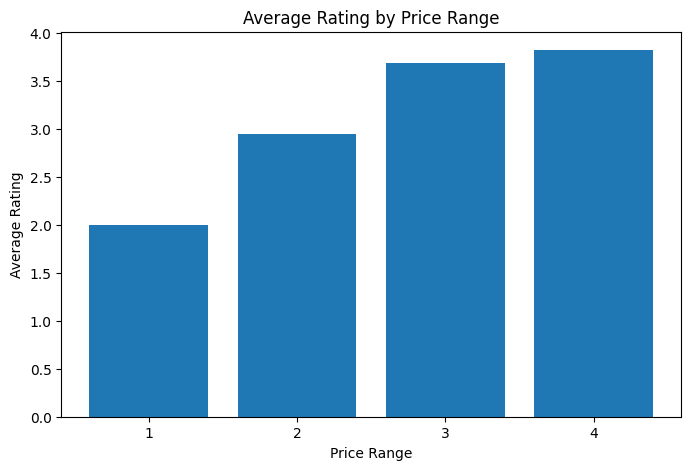

,Price range,Aggregate rating
0,1,1.999887
1,2,2.941054
2,3,3.683381
3,4,3.817918


In [46]:
# Average rating according to approximate cost
cost_rating = final_df.groupby('Price range')['Aggregate rating'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(cost_rating['Price range'].astype(str), cost_rating['Aggregate rating'])
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()

cost_rating

## 10. Cuisine Analysis

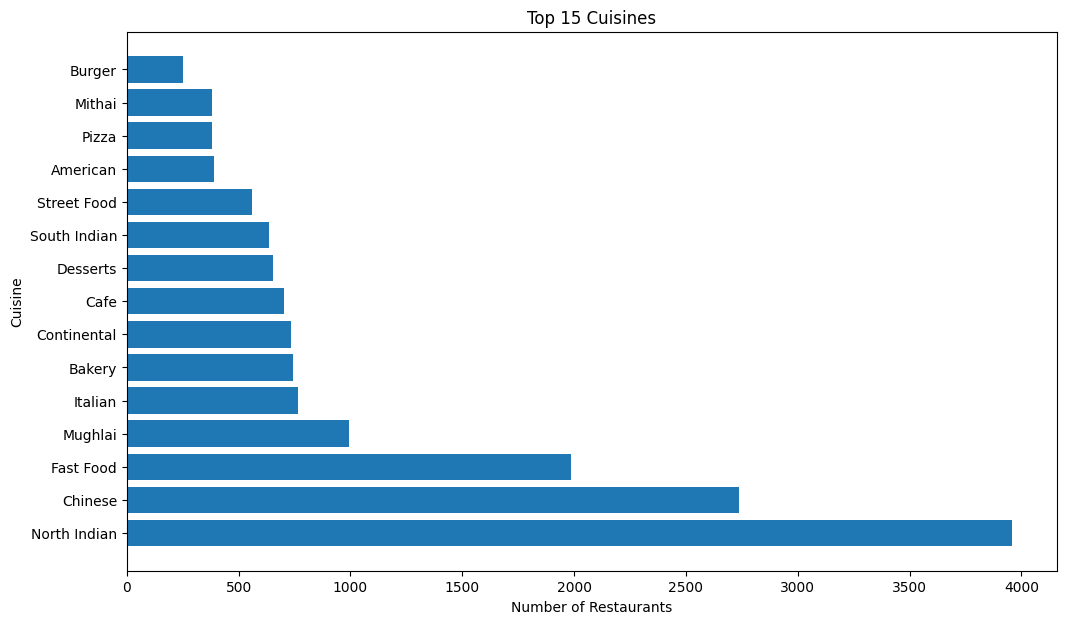

In [47]:
# Top cuisines based on the first listed cuisine
cuisine_counts = (
    final_df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,7))
plt.barh(cuisine_counts.index, cuisine_counts.values)
plt.title("Top 15 Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()

## 11. Correlation Analysis

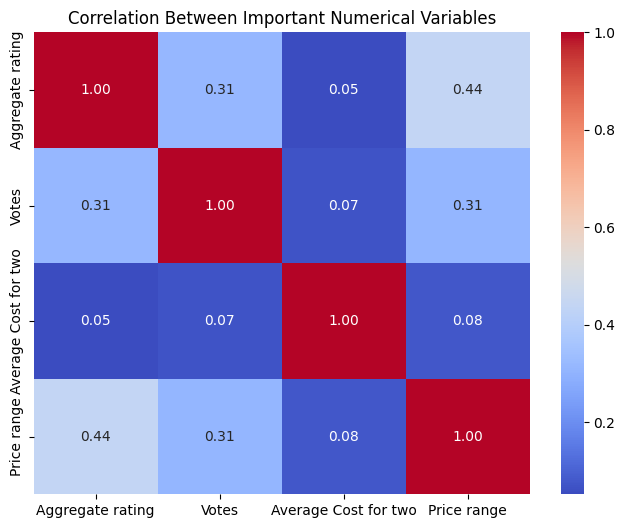

In [48]:
# Correlation among important numerical variables
numeric_columns = [
    'Aggregate rating',
    'Votes',
    'Average Cost for two',
    'Price range'
]

correlation = final_df[numeric_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Important Numerical Variables")
plt.show()

## 12. Key Business Insights

In [49]:
# Generate a few direct numerical insights from the dataset

print("Total restaurants:", len(final_df))
print("Total countries:", final_df['Country'].nunique())
print("Total cities:", final_df['City'].nunique())

print("\nMost common country:")
print(final_df['Country'].value_counts().idxmax())

print("\nMost common city:")
print(final_df['City'].value_counts().idxmax())

print("\nMost common rating:")
print(final_df['Aggregate rating'].mode()[0])

print("\nRestaurants with online delivery:")
print((final_df['Has Online delivery'] == 'Yes').sum())

print("\nRestaurants with table booking:")
print((final_df['Has Table booking'] == 'Yes').sum())

Total restaurants: 9551
Total countries: 15
Total cities: 141

Most common country:
India

Most common city:
New Delhi

Most common rating:
0.0

Restaurants with online delivery:
2451

Restaurants with table booking:
1158


## 13. Conclusion

The analysis provides an overview of Zomato's restaurant ecosystem using restaurant
location, ratings, votes, pricing, cuisines, online delivery and table-booking data.

The visualizations help identify popular restaurant locations, common rating patterns,
customer engagement through votes, pricing trends and service availability.

This project demonstrates the use of Python, Pandas, Matplotlib and Seaborn for
data cleaning, exploratory analysis, visualization and business-oriented insight generation.